### **Monitoring**: Importance of exploration

![Exploration Analysis](img/Exploration_Analysis.jpg)

### **Analysis & Planning**: Prediction Accuracy

In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from agent.components import RASK
from agent.components.GaussianProcess import get_empirical_variable_bounds
from agent.components.SLORegistry_v2 import calculate_weighted_SLO_F
from agent.components.commons import ServiceType, SloSet, ServiceVar, SERVICE_STYLE
from notebooks.summersoc.globals import PATH_METRICS_DEMO_EXPLORE, PATH_METRICS_DEMO_EXPLOIT


plt.style.use('default')

services = [ServiceType.QR, ServiceType.CV, ServiceType.PC]
slos = [SloSet.DEFAULT, SloSet.HIGH_PERF, SloSet.LOW_COST, SloSet.HIGH_QUALITY]

_df_explore = pd.read_csv(PATH_METRICS_DEMO_EXPLORE)
_df_exploit = pd.read_csv(PATH_METRICS_DEMO_EXPLOIT)
df_joint = pd.concat([_df_explore, _df_exploit])
df_preprocessed = RASK.preprocess_data(df_joint)

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str


In [2]:

empirical_bounds = {s: get_empirical_variable_bounds(df_preprocessed)[s] for s in services}

df_candidates = pd.read_csv('../../statics/candidates/candidate_solutions_20_100_50.csv')
df_physical = RASK.preprocess_data(
    pd.read_csv('../../statics/agent_experience/metrics_ICSOC_candidate_solutions_20_100_50.csv'))

if len(df_candidates) != len(df_physical):
    raise RuntimeError(f"Length mismatch! {len(df_candidates)} candidates vs {len(df_physical)} physical rows.")


INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str


In [3]:

def compute_actual_f(idx):
    c, p = df_candidates.iloc[idx], df_physical.iloc[idx]
    s_type = ServiceType(c['service_type'])
    state = {ServiceVar.COST: p['cores'], ServiceVar.QUALITY: c['data_quality'], ServiceVar.PERFORMANCE: p['max_tp']}
    if s_type == ServiceType.CV: state[ServiceVar.MODEL] = c['model_size']
    return calculate_weighted_SLO_F(state, SloSet[c['slo_set']].value, empirical_bounds[s_type])


# --- 1. Define the Metric Logic ---
def analyze_group(group, beta):
    """Standardized logic to compute metrics for any grouped slice of data."""
    actual = group['actual_fitness']
    pred = group['p_fitness']

    # Calculate Shortfall (Predicted > Actual)
    # This captures the 'Dangerous Optimism' you want to penalize
    shortfall_series = pred - actual
    positive_shortfalls = shortfall_series[shortfall_series > 0]

    # Calculate Shortfalls (Predicted > Actual)
    # We set all 'pleasant surprises' (Actual >= Predicted) to 0
    shortfall_errors = pred - actual
    shortfall_errors = shortfall_errors.clip(lower=0)

    # Structural Mirror of RMSE:
    # 1. Square the errors
    # 2. Mean of the squares
    # 3. Square root of the mean
    rmss = np.sqrt(np.mean(shortfall_errors ** 2))
    avg_f = actual.mean()

    return {
        'avg_shortfall': rmss,
        'fitness': avg_f,
        'readiness': avg_f - (rmss * beta),
        'samples': len(group)
    }


# --- 2. Calculate Actual Fitness (The Ground Truth) ---
df_candidates['actual_fitness'] = [compute_actual_f(i) for i in range(len(df_candidates))]

# --- 3. Execute Analysis with Groupby ---
BETA = 2.5
global_res = []
slo_res = []

# Global grouping
for keys, group in df_candidates.groupby(['service_type', 'data_rate']):
    metrics = analyze_group(group, BETA)
    global_res.append({'service': keys[0], 'data_rate': keys[1], **metrics})

# SLO-specific grouping
for keys, group in df_candidates.groupby(['service_type', 'data_rate', 'slo_set']):
    metrics = analyze_group(group, BETA)
    slo_res.append({'service': keys[0], 'data_rate': keys[1], 'slo_set': keys[2], **metrics})

df_global = pd.DataFrame(global_res)
df_slo = pd.DataFrame(slo_res)

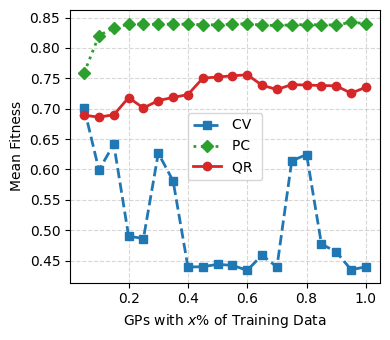

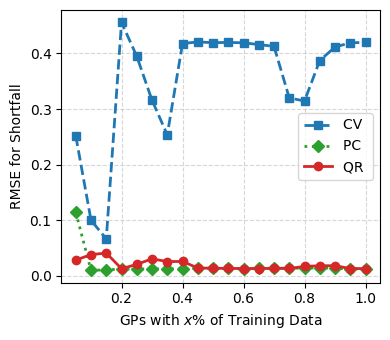

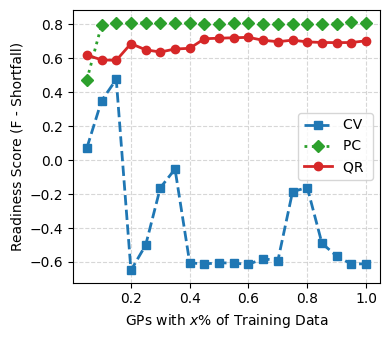

In [6]:
from agent.components.commons import FIG_SIZE_3_ROW


def plot_service_line(ax, data, column, label_suffix=""):
    for service in data['service'].unique():
        svc_data = data[data['service'] == service].sort_values('data_rate')
        style = SERVICE_STYLE.get(service)

        ax.plot(svc_data['data_rate'], svc_data[column],
                label=f"{service.split('-')[2].upper()} {label_suffix}",
                **style, linewidth=2)


### 3. Global Plots (RMSE, Fitness, and Global Confidence)
# Added 'conf' to this loop to get the aggregated Reliable Performance plot
metrics = [
    ('fitness', 'slof_convergence', 'Mean Fitness'),
    ('avg_shortfall', 'rmss_convergence', 'RMSE for Shortfall'),
    ('readiness', 'readiness_global', 'Readiness Score (F - Shortfall)')
]

for col, name, ylabel in metrics:
    fig, ax = plt.subplots(figsize=FIG_SIZE_3_ROW, facecolor='white')
    plot_service_line(ax, df_global, col)
    ax.set_xlabel(fr'GPs with $x$% of Training Data')
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()